In [1]:
%matplotlib inline

from datetime import datetime, timedelta
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


from utils import process

# default 2 decimal places for printing floats
pd.set_option('display.float_format', '{:.2f}'.format)


files = Path("./data").glob("*.txt")
most_recent = sorted(files)[-1]

df = pd.DataFrame(process(most_recent)).set_index("datetime").sort_index()
df["solve_number"] = range(1, df.shape[0]+1)

df["session_id"] =df["session_id"].astype(int)

cutoff = datetime.now() + timedelta(days=-7)

df["in_last_week"] = df.index >= cutoff
df

,session_id,state,time_ms,solve_number,in_last_week
datetime,,,,,
2026-02-09 08:43:35,1,0,46034,1,False
2026-02-09 08:50:55,1,0,59276,2,False
2026-02-09 08:55:29,1,-1,54276,3,False
2026-02-09 09:04:18,1,0,68041,4,False
2026-02-10 12:51:13,2,-1,19919,5,False
...,...,...,...,...,...
2026-03-11 10:41:52,24,0,37701,350,True
2026-03-11 10:43:19,24,0,33132,351,True
2026-03-11 10:45:56,24,0,32551,352,True


In [2]:
# map sessions to cubes
cubes = {
    1: "Rubik's",
    2: "MoYu WRM v9",
    3: "MoYu WRM v10",
}

# start session: cube
cubemap = {
    1: 1,
    16: 2,
}

bins = [*cubemap.keys(), np.inf]
labels = [cubes[cubemap[k]] for k in cubemap]

df["cube"] = pd.cut(df.session_id, bins=bins, labels=labels, right=False, ordered=False)

In [3]:
# filter to valid times and calculate averages

valid_times = df[df.state == 0]

def trimmed_mean(series: pd.Series, skip=1):
    """Calculates average of n by removing the best & worst values (determined by param skip, symmetrically)
        i.e. n=5, skip=1 will calculate the mean of the 3 middle values of 5
    """
    sorted = np.sort(series)
    return sorted[skip:-skip].mean()

def rolling_ao(series: pd.Series, n=5, skip=1):
    return series.rolling(n).apply(trimmed_mean, raw=True)

# averages
valid_times["ma10"] = valid_times.time_ms.rolling(window=10).mean()
valid_times["ao5"] = rolling_ao(valid_times.time_ms, 5, 1)
valid_times["ao12"] = rolling_ao(valid_times.time_ms, 12, 1)
valid_times["ao100"] = rolling_ao(valid_times.time_ms, 100, 5)

# st dev
valid_times["rolling_std10"] = valid_times.time_ms.rolling(window=10).std()

valid_times["is_pb"] = valid_times.time_ms.cummin() == valid_times.time_ms

valid_times.tail()


,session_id,state,time_ms,solve_number,in_last_week,cube,ma10,ao5,ao12,ao100,rolling_std10,is_pb
datetime,,,,,,,,,,,,
2026-03-11 10:41:52,24,0,37701,350,True,MoYu WRM v9,35206.80,35205.00,33776.60,36119.26,4360.80,False
2026-03-11 10:43:19,24,0,33132,351,True,MoYu WRM v9,35509.30,35231.00,34200.70,35953.72,4062.44,False
2026-03-11 10:45:56,24,0,32551,352,True,MoYu WRM v9,35079.60,34461.33,34512.00,35909.29,4131.77,False
2026-03-11 10:47:19,24,0,27503,353,True,MoYu WRM v9,34140.20,34461.33,34445.10,35787.62,4701.31,False
2026-03-11 10:48:43,24,0,35194,354,True,MoYu WRM v9,34715.80,33625.67,34279.70,35740.61,4404.64,False


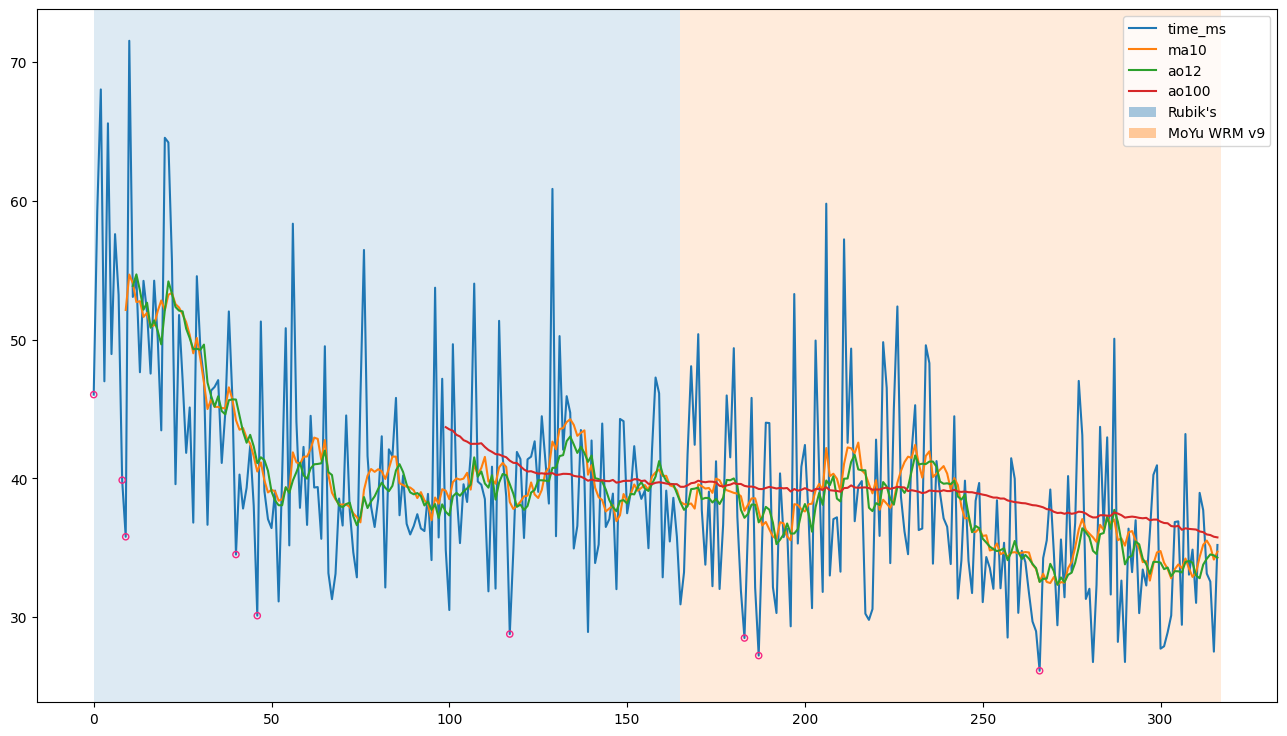

In [4]:
# plot times
columns = [
    "time_ms",
    "ma10",
    # "ao5",
    "ao12",
    "ao100",
]


ax = (valid_times[columns] / 1000).reset_index(drop=True).plot.line(figsize=(16,9))

# highlight PBs
mask = valid_times.is_pb.values
x_positions = np.where(mask)[0]

ax.scatter(
    x_positions,
    valid_times.loc[mask, "time_ms"]/1000,
    facecolors='none',
    edgecolors="#f62681",
    linewidths=1,
    zorder=5,
    s=20,
    marker="o"
)

# background color by cube
cubes = valid_times.cube.reset_index(drop=True)
colors = {category: plt.cm.tab10(i) for i, category in enumerate(cubes.unique())}
changes = cubes.ne(cubes.shift()).to_numpy().nonzero()[0].tolist() + [len(cubes)]

for start, end in zip(changes, changes[1:]):
    ax.axvspan(start, end, alpha=.15, color = colors[cubes.iloc[start]], lw=0)

# set up labels
from matplotlib.patches import Patch
cube_handles = [Patch(facecolor=colors[cat], alpha=0.4, label=cat) for cat in cubes.unique()]
line_handles, line_labels = ax.get_legend_handles_labels()
ax.legend(handles=line_handles + cube_handles, labels=line_labels + list(cubes.unique()))

plt.show()


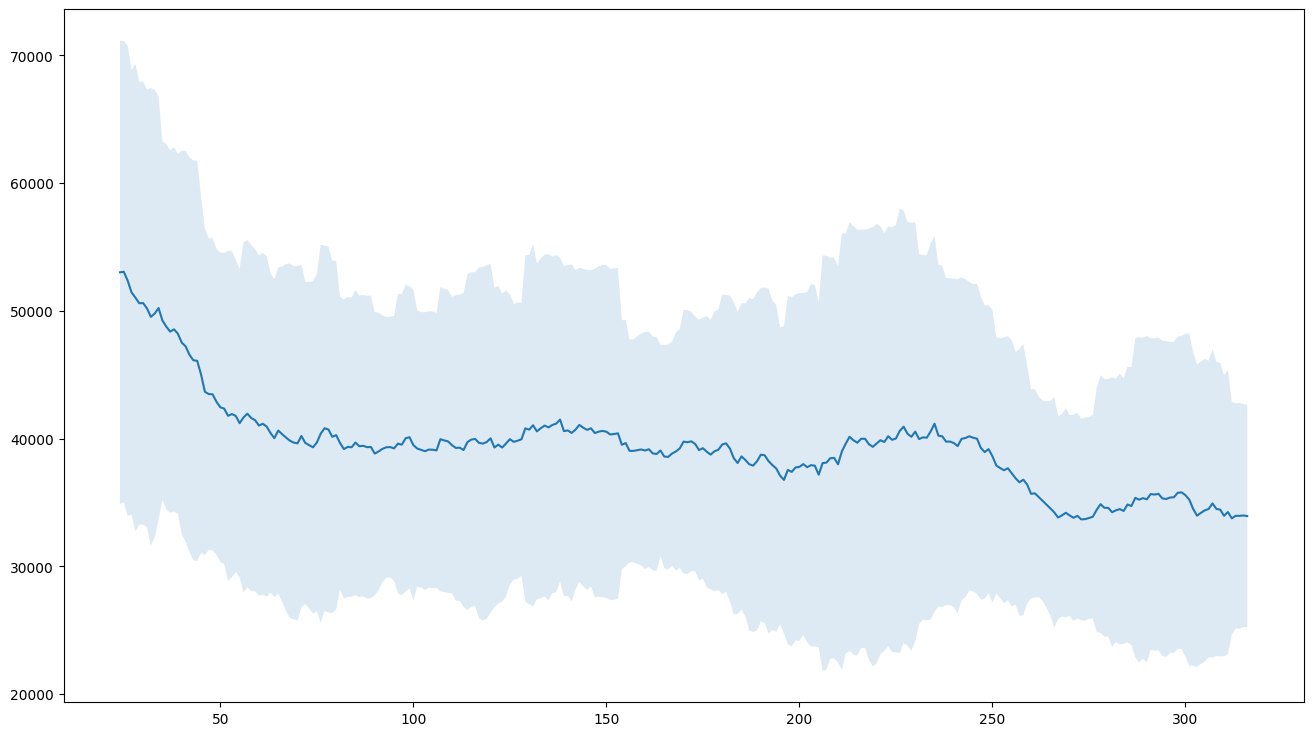

In [5]:
n = 25

rolling = valid_times.time_ms.reset_index(drop=True).rolling(window=n)

rolling_mean = rolling.mean()
rolling_std = rolling.std()

ax = rolling_mean.plot.line(figsize=(16,9))

ax.fill_between(
    np.arange(len(rolling_mean)),
    rolling_mean - 2*rolling_std,
    rolling_mean + 2*rolling_std,
    alpha=.15
)
plt.show()

In [6]:
print("Last week stats")
(valid_times.time_ms / 1000).describe()

(valid_times[valid_times.in_last_week].time_ms / 1000).describe()

Last week stats


count   67.00
mean    34.36
std      5.06
min     26.12
25%     31.05
50%     33.42
75%     36.87
max     50.06
Name: time_ms, dtype: float64

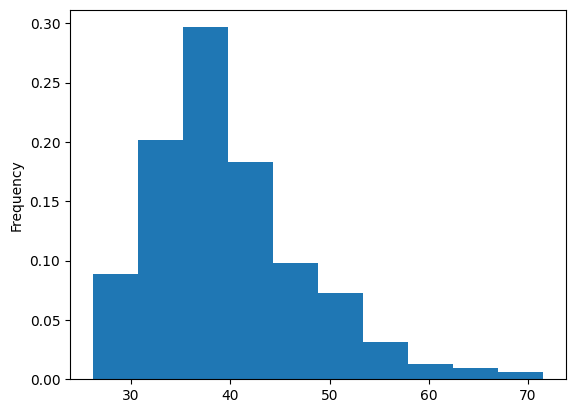

In [7]:
(valid_times.time_ms / 1000).plot.hist(weights = np.ones(len(valid_times)) / len(valid_times))
plt.show()

In [8]:
# PBs
pbs = valid_times[valid_times.is_pb]
pbs["diff_ao100"] = pbs.ao100 - pbs.time_ms
pbs["improvement"] = pbs.time_ms.shift() - pbs.time_ms

pbs["held"] = pbs.index.to_series().shift(-1) - pbs.index.to_series()

# suppress float decimals since they are ms anyways
with pd.option_context("display.float_format", '{:.0f}'.format):
    cols = [
        "session_id",
        "solve_number",
        "cube",
        "time_ms",
        "improvement",
        "ao100",
        "diff_ao100",
        "held",
    ]
    display(pbs[cols])

,session_id,solve_number,cube,time_ms,improvement,ao100,diff_ao100,held
datetime,,,,,,,,
2026-02-09 08:43:35,1,1,Rubik's,46034,NaN,NaN,NaN,2 days 07:06:30
2026-02-11 15:50:05,3,13,Rubik's,39869,6165,NaN,NaN,0 days 00:01:48
2026-02-11 15:51:53,3,14,Rubik's,35784,4085,NaN,NaN,6 days 02:02:32
2026-02-17 17:54:25,7,51,Rubik's,34503,1281,NaN,NaN,2 days 01:10:45
2026-02-19 19:05:10,8,59,Rubik's,30094,4409,NaN,NaN,1 days 15:25:29
2026-02-21 10:30:39,12,144,Rubik's,28769,1325,41273,12504,4 days 23:37:07
2026-02-26 10:07:46,17,210,MoYu WRM v9,28483,286,39456,10973,0 days 00:07:45
2026-02-26 10:15:31,17,214,MoYu WRM v9,27217,1266,39232,12015,8 days 00:31:52
2026-03-06 10:47:23,21,300,MoYu WRM v9,26122,1095,37983,11861,NaT


In [9]:
# per cube stats
valid_times.groupby("cube").agg(
    count=("solve_number", len),
    mean=("time_ms", np.mean),
    stdev=("time_ms", np.std),
    min=("time_ms", min),
    max=("time_ms", max),

)


,count,mean,stdev,min,max
cube,,,,,
Rubik's,165,42282.79,7938.77,28769,71549
MoYu WRM v9,152,36923.40,6524.10,26122,59802


# Milestones
- [x] Sub-30 single
- [] Sub-25 single
- [] Sub-30 ao12
- [] Sub-30 ao100
- [] Sub-20 single
- [] Sub-20 ao12
- [] Sub-20 ao100
- [] 90% sub-20